In [1]:
# Davy Oild Field - Parameters and Setup 
# =============================================================

import numpy as np
from scipy.optimize import fsolve


r = 0.077           # constant discount rate , assumed as industry standard WACC hurdle rate 8% means 0.77 continous discount rate 
mu_2 = 0.015 - 0.04     # expected revenue growth rate , minus 0.04 giving ncy (delta) = 10.2%
sigma_2 = 0.45     # revenue volatility - ICE UK NBP natural gas futures historical volatility


mu_1 = 150         # 150% a year - so takes about 8 months
sigma_1 = 25       # dismantling volatility 25% 
c = 54.75          # dismantling costs (p.a.)  (£54.75m a year) (£150k a day) 

x_star = 100       # finish line 100% 


eta = 3.65         # operating costs (p.a.) (£3.65m a year) 
k = 0.73           # mothball 
K_restart = 2      # restart cost (without repair)


a = 0.5 * sigma_2**2             # finding roots of the characterstic eqn 
b = mu_2 - (0.5 * sigma_2**2)
c_1 = -r

roots = np.roots([a, b, c_1])
beta_1 = max(roots)  
beta_2 = min(roots)  




In [2]:
# Calculations for right wall 


h = 0.1       # step size 

raw_z_min = -10.0                        # calculations for how many rows there will be 
z_min = h * np.floor(raw_z_min / h)      # 

raw_z_max = np.log(2000) 
z_max = h * np.ceil(raw_z_max / h)    # smallest multiple of h in excess of z such that z ≥ log(10yI) 

print( z_min , z_max)

z_labels = np.arange(z_min, z_max + h, h)    # array of values stepping in h 

finish_line_column = np.zeros(len(z_labels))  #  column of zeros 



print("--- Z-TRANSFORMED FINISH LINE BUILT ---")
print(f"Total rows in new grid: {len(z_labels)}")
print(f"Bottom row Z: {z_labels[0]:.2f} (which is £{np.exp(z_labels[0]) * 1000:.1f}m revenue)")
print(f"Top row Z: {z_labels[-1]:.2f} (which is £{np.exp(z_labels[-1]) * 1000:.1f}m revenue)")

-10.0 7.7
--- Z-TRANSFORMED FINISH LINE BUILT ---
Total rows in new grid: 178
Bottom row Z: -10.00 (which is £0.0m revenue)
Top row Z: 7.70 (which is £2208348.0m revenue)


In [3]:
# Transition Probabilities 


rho = 0 
Q_xz = (sigma_1)**2 + (sigma_2)**2 - abs(rho)*sigma_1*sigma_2 + abs(mu_1)*h + abs(mu_2-(((sigma_2)**2)/2))*h
delta_t_xz = h**2 / Q_xz  # this is what allows the coefficients to act as transition probabilities , since it acts a normalization factor and makes them sum to 1

p1 = ((sigma_1**2 - abs(rho)*sigma_1*sigma_2)/2 + np.maximum(0,h*mu_1))/Q_xz 
p2 = ((sigma_2**2 - abs(rho)*sigma_1*sigma_2)/2 + np.maximum(0,h*(mu_2 - (sigma_2**2)/2) ))/Q_xz       # also ingored rho here since its 0 , 
p3 = ((sigma_1**2 - abs(rho)*sigma_1*sigma_2)/2 + np.maximum(0,h*-mu_1))/Q_xz
p4 = ((sigma_2**2 - abs(rho)*sigma_1*sigma_2)/2 + np.maximum(0,h*-(mu_2 - (sigma_2**2)/2) ))/Q_xz

print(p1,p2,p3,p4, f"total: {p1+p2+p3+p4}" )
print(f"Q is: {Q_xz}")
print(f"delta t is: {delta_t_xz}")


x_min = -100   # need some rows before 0% 
x_max = 100  # 


x_labels = np.arange(x_min, x_max + h, h)   # array of values stepping in h 

num_x_cols = len(x_labels)      # number of columns 
num_z_rows = len(z_labels)      # number of rows 


F_grid = np.zeros((num_z_rows, num_x_cols))    # create grid of zeros , numpy does rows then columns , instead of (x,y) its (y,x) 

                         

# TOP WALL - when revenues are high , we assume we would definitely restart 
V_operate_max = (np.exp(z_max)/(r-mu_2)) - (eta/r)
clamped_x = np.maximum(0, x_labels)   # cant let x be negative 
K_repair = 2*(np.exp((4.11/100)*clamped_x) -1)

F_grid[-1, :] = V_operate_max - K_repair - K_restart                                                     

# ==================================

R_a = 0.5 * sigma_1**2
R_b = mu_1
R_c = -r
roots = np.roots([R_a, R_b, R_c])
alpha_1 = max(roots)  
print(alpha_1)



bottom_wall= -(1-(np.exp(alpha_1*(x_labels-x_max))))*(c/r)  # here there is 0% chance of restarting 

F_grid[0, :] = bottom_wall                                      
# F_grid[:, 0] = np.linspace(-K_restart, top_wall[0], num_z_rows)  # linear interpolation for left wall   !!!!not sure we need this !!!!!
left_wall = F_grid[:,0]

F_grid[:, -1] = finish_line_column   # right wall                             
                          


0.5115468023346059 0.00015814996560726367 0.4881171778001965 0.00017786989959039161 total: 1.0
Q is: 640.215125
delta t is: 1.561974968960629e-05
0.0005127855229322315


In [4]:
# LOOP 
# ==================================================

start_row_i = 1  #  must start above row 0 
V_operate = (np.exp(z_labels)/(r-mu_2)) - (eta/r)

# Reshape them into a column and a row
V_operate_col = V_operate.reshape(-1, 1)
K_repair_row = K_repair.reshape(1, -1) 

Option_A_full = V_operate_col - K_repair_row - K_restart

Option_A =  Option_A_full[start_row_i:-1, 1:-1]   # need a matrix of the restart option at every point 


max_iterations = 400000  
tolerance = 1e-8



check_interval = 1000 

for iteration in range(max_iterations):
    
    
    F_old = np.copy(F_grid)   # create a copy to do a sweep on , we dont need to do calculations below y_A 

    
    
    F_right = F_old[start_row_i:-1, 2:]      # delete rows and columns to create 'shifted' matrices to do vector calculations simulatiing up down left and right moves
    F_up    = F_old[start_row_i+1:, 1:-1]    
    F_left  = F_old[start_row_i:-1, :-2]     
    F_down  = F_old[start_row_i-1:-2, 1:-1]  
    
    
    L_F_xz = (p1 * F_right) + (p2 * F_up) + (p3 * F_left) + (p4 * F_down)   
    Option_B = ((1 - (r * delta_t_xz)) * L_F_xz) - (c * delta_t_xz)                        
      
    
    F_grid[start_row_i:-1, 1:-1] = np.maximum(Option_A, Option_B)   # bellman eqn 
             
    
    if iteration % check_interval == 0 and iteration > 0:    # 
        max_diff = np.max(np.abs(F_grid - F_old))
        print(f"Sweep {iteration}... Max Diff: {max_diff:.6f}")
        
        if max_diff < tolerance:
            print(f"Grid converged successfully after {iteration} iterations!")
            break
        
if iteration == max_iterations - 1:
    print("Warning: Hit max_iterations without fully converging.")





            

Sweep 1000... Max Diff: 0.009210
Sweep 2000... Max Diff: 0.006813
Sweep 3000... Max Diff: 0.005203
Sweep 4000... Max Diff: 0.004085
Sweep 5000... Max Diff: 0.003288
Sweep 6000... Max Diff: 0.002795
Sweep 7000... Max Diff: 0.002593
Sweep 8000... Max Diff: 0.002395
Sweep 9000... Max Diff: 0.002210
Sweep 10000... Max Diff: 0.002040
Sweep 11000... Max Diff: 0.001886
Sweep 12000... Max Diff: 0.001747
Sweep 13000... Max Diff: 0.001642
Sweep 14000... Max Diff: 0.001582
Sweep 15000... Max Diff: 0.001522
Sweep 16000... Max Diff: 0.001458
Sweep 17000... Max Diff: 0.001391
Sweep 18000... Max Diff: 0.001324
Sweep 19000... Max Diff: 0.001266
Sweep 20000... Max Diff: 0.001236
Sweep 21000... Max Diff: 0.001205
Sweep 22000... Max Diff: 0.001174
Sweep 23000... Max Diff: 0.001143
Sweep 24000... Max Diff: 0.001111
Sweep 25000... Max Diff: 0.001081
Sweep 26000... Max Diff: 0.001060
Sweep 27000... Max Diff: 0.001044
Sweep 28000... Max Diff: 0.001027
Sweep 29000... Max Diff: 0.001010
Sweep 30000... Max Diff

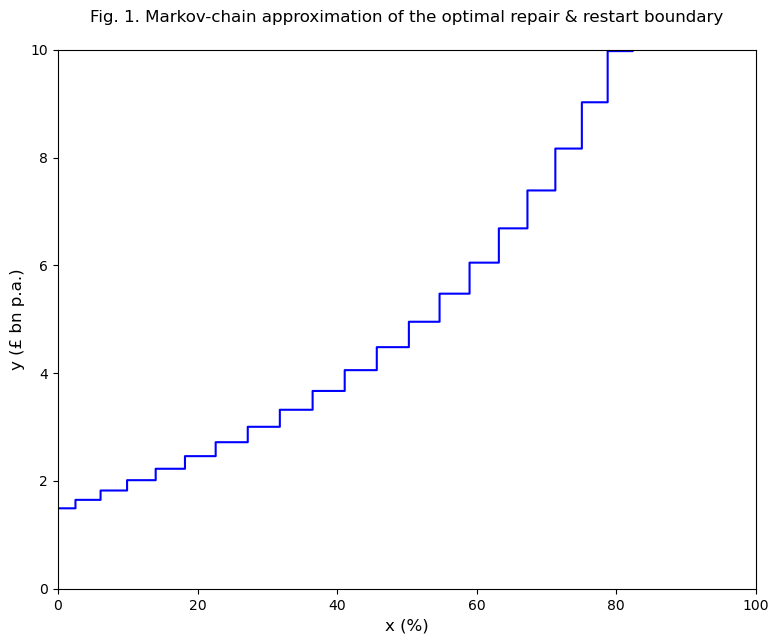

In [6]:
# Boundary Line Graph


import matplotlib.pyplot as plt


boundary_y_values = []
x_plot = []


for j in range(len(x_labels)):
    
    
    
    if x_labels[j] >= 0:
        
        column_values = F_grid[:, j]
        #restart_values = Option_A[:,j]
        
        #eject_zone_rows = np.argmax(column_values > restart_vaues)
        eject_zone_rows = np.where(column_values >= Option_A_full[:,j] + 1e-5)[0]
        
        if len(eject_zone_rows) > 0:
            
            highest_eject_row = eject_zone_rows[-1]
            boundary_z = z_labels[highest_eject_row]
            
            
            boundary_y_values.append(np.exp(boundary_z))
        else:
            
            boundary_y_values.append(np.exp(z_labels[0]))
        
        x_plot.append(x_labels[j])




plt.figure(figsize=(9, 7))

#plt.step(x_plot, boundary_y_values_no_ncy, where='post', color='black', linewidth=1.5)    ## used here for comparing to other values , run code twice with this un commented.
plt.step(x_plot, boundary_y_values, where='post', color='blue', linewidth=1.5)


plt.title("Fig. 1. Markov-chain approximation of the optimal repair & restart boundary", fontsize=12, pad=20)
plt.xlabel("x (%)", fontsize=12)
plt.ylabel("y (£ bn p.a.)", fontsize=12)


plt.xlim(0, 100)
plt.ylim(0, 10)


plt.savefig('Davy_Field_Boundary_Graph.png', dpi=300, bbox_inches='tight')  

plt.show()

In [7]:
# Decomission trigger at 0 %
print(f"To cancel demolition at the start is when revenues are £{1000*boundary_y_values[0]:.2f} million")


To cancel demolition at the start is when revenues are £1491.82 million


In [8]:
from scipy.optimize import fsolve

# We only have ONE trigger (Restarting directly from mothball)

def mothball_restart_equations(variables):
    y_I, A = variables
    
    # Eq 1: Value Matching at y_I 
    eq1 = (A * y_I**beta_1) - (k/r) - ((y_I / (r - mu_2)) - (eta/r) - K_restart)
    
    # Eq 2: Smooth Pasting at y_I
    eq2 = (A * beta_1 * y_I**(beta_1 - 1)) - (1 / (r - mu_2))
    
    return [eq1, eq2]

# Initial guesses: £10m for y_I, 1.0 for A
initial_guess = [10.0, 1.0]

solution = fsolve(mothball_restart_equations, initial_guess)
y_I_mothball = solution[0]

print(f"Optimal Restart Trigger (from Mothball), we would need revenues to hit: £{y_I_mothball:.2f} million")

Optimal Restart Trigger (from Mothball), we would need revenues to hit: £9.93 million


In [ ]:
#boundary_y_values_no_ncy = boundary_y_values 